# Baseline

## Общая инициализация
Нужно выполнить в самом начале независимо от дальнейших действий

### Путь к каталогу, в котором лежит датасет
датасет представлен файлом `train.csv` и папкой `train`

In [1]:
import os
import random

import librosa
import librosa.feature as F

import numpy as np

import matplotlib.pyplot as plt

from IPython.display import Audio

In [2]:
base_folder = ""

#### Инициализация путей 

In [3]:
import os.path as path
import zipfile

In [4]:
# path
train_folder = path.join(base_folder, "lab2_dataset")
train_csv = path.join(base_folder, "lab2_train.csv")
train_pickle = path.join(base_folder, "train.pickle")
labels_pickle = path.join(base_folder, "labels.pickle")

### Изучение аудиофайлов датасета

In [5]:
archive = "audio_train.zip"
directory_to_extract_to = train_folder
os.makedirs(directory_to_extract_to, exist_ok=True)

# Извлекаем из .zip файлы
with zipfile.ZipFile(archive, 'r') as zip_file:
    zip_file.extractall(directory_to_extract_to)

In [6]:
train_folder = os.path.join(train_folder, "train")

In [7]:
# random filename from dir
files = os.listdir(train_folder)
filename = random.choice(files)
filename

'38e096542f420bff9573.wav'

#### Спектрограмма

In [8]:
# spectrogram parameters
sample_rate = 11025

/Users/ivanguseff/VScode/AcousticEvents/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


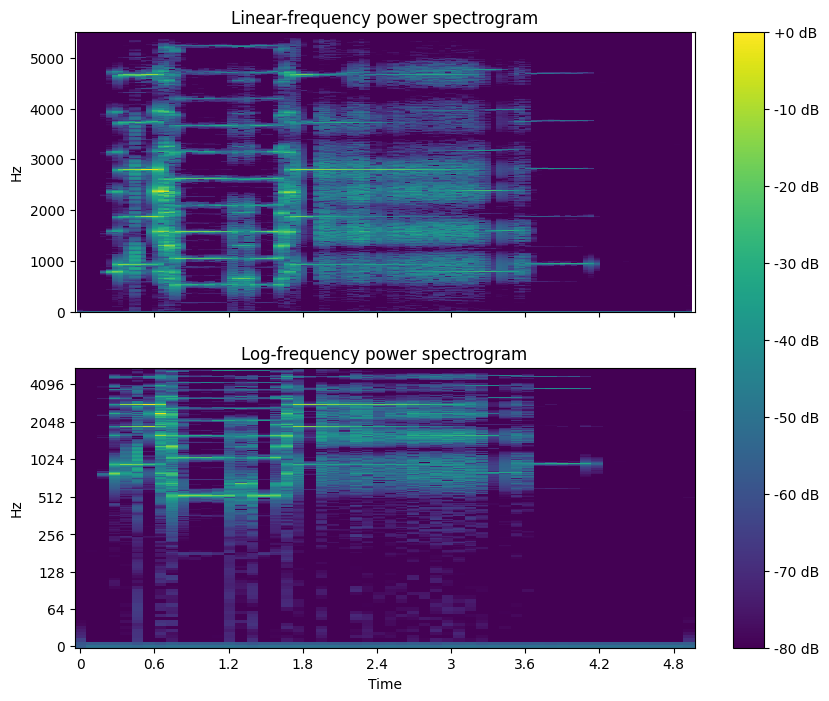

In [9]:
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=sample_rate)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

# draw linear-frequency spectrogram
hop_length = 512
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img1 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_top,
    x_axis='time',
    y_axis='linear',
    cmap=cmap,
)
ax_top.set(title='Linear-frequency power spectrogram')
ax_top.label_outer()

# draw log-frequency spectrogram
hop_length = 1024
wav_data_db = librosa.amplitude_to_db(
    np.abs(librosa.stft(wav_data, hop_length=hop_length)),
    ref=np.max
)
img2 = librosa.display.specshow(
    wav_data_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_bottom,
    x_axis='time',
    y_axis='log',
    cmap=cmap,
)
ax_bottom.set(title='Log-frequency power spectrogram')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

#### Mel-спектрограмма

In [10]:
# melspectrogram parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

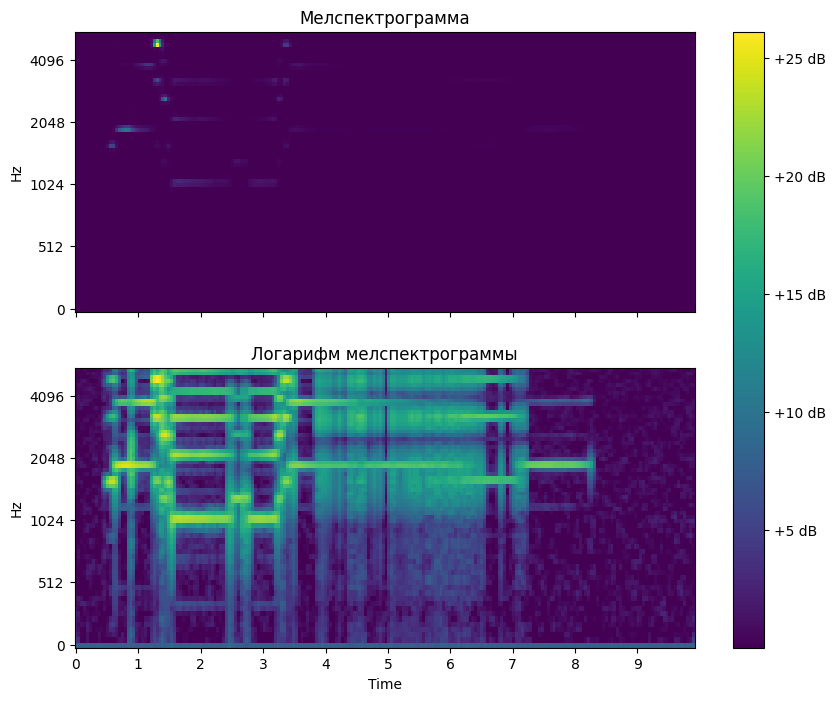

In [11]:
wav_data, sr = librosa.load(os.path.join(train_folder,filename), sr=sample_rate)

mel_spec = F.melspectrogram(
    y=wav_data,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels, 
    fmax=sample_rate // 2
)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

img1 = librosa.display.specshow(
    mel_spec,
    sr=sr,
    fmax=sr // 2,
    ax=ax_top,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_top.set(title='Мелспектрограмма')
ax_top.label_outer()

D = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(
    D,
    sr=sr,
    fmax=sr // 2,
    ax=ax_bottom,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_bottom.set(title='Логарифм мелспектрограммы')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

display(Audio(wav_data, rate=sr))

## Извлечение признаков

In [12]:
import os
import pickle
from enum import Enum
from typing import NoReturn, Optional

from tqdm import tqdm

import pandas as pd
import numpy as np

import librosa
import librosa.feature as F


class SetType(Enum):
    """Set type"""
    TRAIN = 1
    TEST  = 2
    DEV   = 3


def extract_log_mel_feats(set_type:SetType, path_to_csv:str, path_to_files:str,
                          out_path:str, labels_pickle:str, sr:Optional[int], n_fft:int,
                          hop_length:int, n_mels:int):
    """
    Extract features from given files and store them in binary format.

    :param set_type: set tyle
    :param path_to_csv: path to loaded csv
    :param path_to_files: path to loaded data
    :param out_path: path to store extracted features
    :param labels_pickle: path to store labels dictionary
    :param sr: input files sample rate
    :param n_fft: size of fft window
    :param hop_length: hop size
    :param n_mels: number of mel band

    :return:
    """
    if set_type not in [SetType.TRAIN, SetType.TEST]:
        raise Exception(f'Such set type not supported: {set_type}')

    feats = []

    if set_type == SetType.TRAIN:
        meta = pd.read_csv(path_to_csv, skiprows=1, names=['fname', 'label'])

        file_names = list(meta['fname'])
        n_files = len(file_names)
        labels = list(meta['label'])

        uniq_labels = np.sort(np.unique(labels))
        label_to_id = {label: i for i, label in enumerate(uniq_labels)}

        print('Total files:', n_files)

        for i, (file_name, label) in tqdm(enumerate(zip(file_names, labels))):
            wav_data, sr = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
            mel_spec = F.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
                'label_id': label_to_id[label]
            })

        pickle.dump(feats, open(out_path, 'wb'))
        pickle.dump(label_to_id, open(labels_pickle, 'wb'))
        return label_to_id
    else:
        for i, file_name in tqdm(enumerate(os.listdir(path_to_files))):
            wav_data, sr = librosa.load(os.path.join(path_to_files, file_name), sr=sr)
            if len(wav_data) == 0:
                wav_data = np.zeros(sr)
            mel_spec = F.melspectrogram(
                y=wav_data,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
            })

        pickle.dump(feats, open(out_path, 'wb'))
        return

In [13]:
# feature extraction parameters
sample_rate = 11025
n_fft = 1024
overlap = 4
hop_length = n_fft // overlap
n_mels = 64

In [14]:
# extract features and store to `train_pickle` extracted features
label_to_id = extract_log_mel_feats(
    SetType.TRAIN,
    train_csv, 
    train_folder, 
    train_pickle,
    labels_pickle,
    sample_rate, 
    n_fft, 
    hop_length, 
    n_mels
)

id_to_label = [label for label, i in label_to_id.items()]

Total files: 5683


5683it [00:42, 133.02it/s]


## Алгоритм детектирования

### Подготовительный этап

In [15]:
from pprint import pprint
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

In [16]:
device = device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [17]:
cpu_count = os.cpu_count()

num_workers = cpu_count if device == "cpu" else 0
num_workers, cpu_count

(8, 8)

#### Добиваемся максимальной воспроизводимости
Согласно данному мануалу: https://pytorch.org/docs/stable/notes/randomness.html

In [18]:
def set_random_state(random_state:int=0) -> NoReturn:
    """Initialize random generators.

    Parameters
    ==========
    random_state : int = 0
        Determines random number generation for centroid initialization.
        Use an int to make the randomness deterministic.
    """
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [19]:
random_state = 42

In [20]:
set_random_state(random_state)

In [21]:
torch.use_deterministic_algorithms(True)

In [22]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8
%env PYTHONHASHSEED=42

env: CUBLAS_WORKSPACE_CONFIG=:4096:8
env: PYTHONHASHSEED=42


### Архитектура нейронной сети

In [23]:
class DummyNetwork(nn.Module):
    """Neural network base architecture"""
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=64, kernel_size=5, stride=(2, 2), device=device)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3, stride=(1, 1), device=device)
        self.conv3 = nn.Conv2d(in_channels=96, out_channels=64, kernel_size=3, stride=(1, 1), device=device)

        self.mp = nn.MaxPool2d(kernel_size=(2, 2), stride=(1, 1))
        
        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)
        self.dropout3 = nn.Dropout(p=0.3)
        
        self.bn1 = nn.BatchNorm2d(num_features=64, device=device)
        self.bn2 = nn.BatchNorm2d(num_features=96, device=device)
        self.bn3 = nn.BatchNorm2d(num_features=64, device=device)

        self.flat = nn.Flatten()

        # 33856 - должно соответствовать форме self.flat
        self.fc1 = nn.Linear(33856, 41, device=device)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout3(x)

        x = self.flat(x)

        # здесь можно еще добавить полносвязный слой или слои
        x = self.fc1(x)

        return x

In [24]:
set_random_state(random_state) # try to run this cell several times
                               # then comment this line and run it several times again
                               # * pay attention at tensors values

# random 4D tensor
random_input = torch.randn(1, 1, 64, 64, requires_grad=True, device=device)

print(f"Исходный тензор {list(random_input.shape)}:")
pprint(random_input)

# create neural network instance
network = DummyNetwork()

# pass data throught the neural network
output = network(random_input)

print(f"\nТензор на выходе нейронной сети {list(output.shape)}:")
pprint(output)

Исходный тензор [1, 1, 64, 64]:
tensor([[[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]]]],
       requires_grad=True)

Тензор на выходе нейронной сети [1, 41]:
tensor([[ 0.5503, -1.1701, -0.3282, -2.0078,  0.6954,  0.0147, -0.3458,  0.8608,
          0.1434, -0.3893, -0.3200,  1.7994, -0.0964, -0.6823, -1.6250,  0.7007,
         -0.5629, -1.5404, -0.7423,  0.2900, -0.4020, -1.1802, -0.1293,  0.4431,
         -0.2631, -0.5873,  0.1059,  1.4210, -0.5620, -0.7153, -1.0673, -0.7911,
         -0.4801,  0.7218,  1.5883,  0.5639, -0.2562, -0.3314,  1.1018,  1.5586,
         -0.5277]], grad_fn=<AddmmBackward0>

### Шаг оптимизации

In [25]:
import torch.optim as optim

In [26]:
set_random_state(random_state)


# choose loss function
criterion = nn.CrossEntropyLoss()

# choose and tune optimizer
optimizer = optim.SGD(network.parameters(), lr=0.001)
optimizer.zero_grad()

random_input = torch.randn(3, 1, 64, 64, requires_grad=True, device=device)
print(f"Тензор на входе сети {list(random_input.shape)}:")
pprint(random_input)

output = network(random_input)
print(f"\nТензор на выходе сети {list(output.shape)}:")
pprint(output)

target = torch.randint(5, (3,), dtype=torch.long, device=device)
print(f"\nТензор с целевыми значениями {list(target.shape)}:")
pprint(target)

loss = criterion(output, target)
print("\nЗначение функции потерь:", loss.item())

# backpropagation
loss.backward()

# next step
optimizer.step() 

Тензор на входе сети [3, 1, 64, 64]:
tensor([[[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]]],


        [[[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
          [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
          [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
          ...,
          [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
          [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
          [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]]],


        [[[-0.7978,  1.0261,  1.1465,  ...,  1.2134,  0.9354,

### Обучение нейронной сети

#### Загрузка ранее извлеченных признаков и подготовка данных для обучения

In [27]:
import pickle

In [28]:
train_data = pickle.load(open(train_pickle, "rb"))

label_to_id = pickle.load(open(labels_pickle, "rb"))
id_to_label = [label for label, i in label_to_id.items()]

In [29]:
def prepare_shape(feature):
    tmp = feature
    N = 64 # размер во времени (можно увеличить, должно стать лучше)
    while tmp.shape[1] < N:
        # можно попробовать сделать np.pad для коротких файлов, вместо повторения до необходимой длины
        tmp = np.hstack((tmp, tmp))
    # случайный сдвиг должен улучшить результат (для этого нужно функцию перенести в EventDetectionDataset)
    tmp = tmp[np.newaxis, :, :N]
    return tmp

In [30]:
# можно улучшить, используя сбалансированное валидационное множество
# гуглить stratified train test split sklearn
validation_set_size = 800

x_val = []
y_val = []

x_tr = []
y_tr = []

for i, row in enumerate(train_data):
    feature = prepare_shape(row['feature'])
    if i < validation_set_size:
        x_val.append(feature)
        y_val.append(row['label_id'])
    else:
        x_tr.append(feature)
        y_tr.append(row['label_id'])

x_val = np.asarray(x_val)
x_tr = np.asarray(x_tr)

y_val = np.asarray(y_val)
y_tr = np.asarray(y_tr)

print(f"""
Train set:
    x.shape: {x_tr.shape}
    y.shape: {y_tr.shape}

Validation set:
    x.shape: {x_val.shape}
    y.shape: {y_val.shape}
""")


Train set:
    x.shape: (4883, 1, 64, 64)
    y.shape: (4883,)

Validation set:
    x.shape: (800, 1, 64, 64)
    y.shape: (800,)



In [31]:
from torch.utils.data import Dataset

In [32]:
class EventDetectionDataset(Dataset):
    def __init__(self, x, y=None, device="cpu"):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # добавить сюда prepare_shape()
        if self.y is not None:
            return \
                torch.tensor(self.x[idx], device=device),\
                torch.tensor(self.y[idx], device=device)

        return torch.tensor(self.x[idx], device=device)

In [33]:
train_dset = EventDetectionDataset(x_tr, y_tr, device=device)
val_dset = EventDetectionDataset(x_val, y_val, device=device)

In [34]:
set_random_state(random_state)

sample_x, sample_y = random.choice(val_dset)

sample_y.item(), id_to_label[sample_y]

(10, np.str_('Cough'))

In [35]:
import librosa
import matplotlib.pyplot as plt

In [36]:
sample_rate = 11025

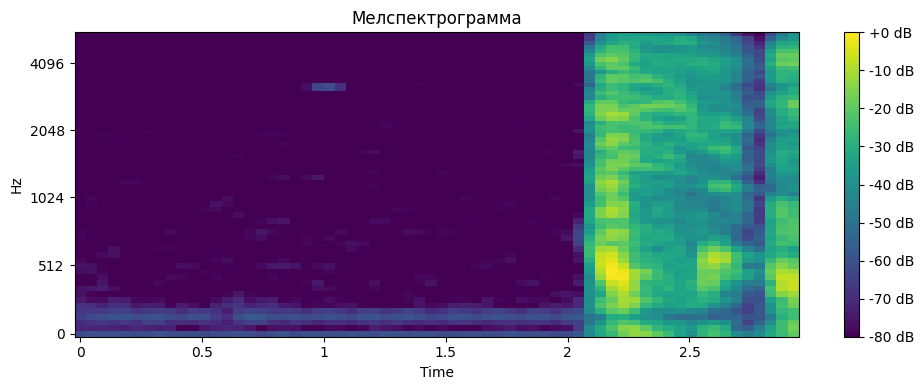

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
cmap = "viridis"

img = librosa.display.specshow(
    sample_x[0].numpy(force=True),
    sr=sample_rate,
    fmax=sample_rate // 2,
    ax=ax,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax.set(title='Мелспектрограмма')
ax.label_outer()

fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.tight_layout()
plt.show()

In [38]:
from torch.utils.data import DataLoader

In [39]:
train_loader = DataLoader(train_dset, batch_size=41, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dset, batch_size=41, shuffle=False, num_workers=num_workers)

In [40]:
import time
from sklearn.metrics import accuracy_score

In [ ]:
start_time = time.time()

n_epoch = 50

set_random_state(random_state)

criterion = nn.CrossEntropyLoss()
network = DummyNetwork()

# можно попробовать другой optimizer, тоже считается улучшением
optimizer = optim.SGD(network.parameters(), lr=0.001)

train_loss = []
val_loss = []

train_acc = []
val_acc = []

for e in range(n_epoch):
    print(f'epoch #{e+1}')

    # train
    loss_list = []
    outputs = []
    targets = []
    for i_batch, sample_batched in enumerate(train_loader):
        x, y = sample_batched
        optimizer.zero_grad()

        output = network(x)
        outputs.append(output.argmax(axis=1))

        target = y
        targets.append(target)

        loss = criterion(output, target.long())
        loss_list.append(loss.item())
        loss.backward()
        optimizer.step()

    y_true = torch.hstack(targets).numpy(force=True)
    y_pred = torch.hstack(outputs).numpy(force=True)
    acc = accuracy_score(y_true, y_pred)

    train_loss.append(np.mean(loss_list))
    train_acc.append(acc)

    print(f'[train] mean loss: {train_loss[-1]}')
    print(f'[train] accuracy:  {acc}')

    loss_list = []
    outputs = []
    targets = []
    with torch.no_grad():
        for i_batch, sample_batched in enumerate(val_loader):
            x, y = sample_batched
            #optimizer.zero_grad()

            output = network(x)
            outputs.append(output.argmax(axis=1))

            target = y
            targets.append(target)

            loss = criterion(output, target.long())
            loss_list.append(loss.item())
            #loss.backward()
            #optimizer.step()

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        acc = accuracy_score(y_true, y_pred)

        val_loss.append(np.mean(loss_list))
        val_acc.append(acc)
        
        print(f'[val] mean loss:   {val_loss[-1]}')
        print(f'[val] accuracy:    {acc}', end="\n\n")

print(f"Execution time: {(time.time() - start_time):.2f} seconds")

epoch #1


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 120, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 130, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'EventDetectionDataset' on <module '__main__' (built-in)>


In [ ]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()

# Grid Search для улучшения модели

Перебираем комбинации параметров:
- **Random chunk**: случайный выбор фрагмента спектрограммы (аугментация данных)
- **Optimizer**: SGD vs Adam
- **Duration**: длительность звука в секундах (2, 3, 4 сек)

In [ ]:
from itertools import product
import pandas as pd

# Grid Search конфигурация
GRID_CONFIG = {
    "random_chunk": [False, True],
    "optimizer": ["SGD", "Adam"],
    "duration": [2, 3, 4]  # секунды
}

# Параметры спектрограммы
SAMPLE_RATE = 11025
N_FFT = 1024
OVERLAP = 4
HOP_LENGTH = N_FFT // OVERLAP
N_MELS = 64

def duration_to_frames(duration_sec):
    """Конвертирует длительность в секундах в количество фреймов спектрограммы"""
    return int(duration_sec * SAMPLE_RATE / HOP_LENGTH)

print("Количество фреймов для каждой длительности:")
for dur in GRID_CONFIG["duration"]:
    print(f"  {dur} сек -> {duration_to_frames(dur)} фреймов")

total_experiments = len(GRID_CONFIG['random_chunk']) * len(GRID_CONFIG['optimizer']) * len(GRID_CONFIG['duration'])
print(f"\nВсего экспериментов: {total_experiments}")

In [ ]:
def prepare_shape_dynamic(feature, n_frames):
    """
    Подготавливает спектрограмму к нужному размеру.
    Если спектрограмма короче n_frames - повторяем.
    Возвращает спектрограмму БЕЗ обрезки (для возможности random shift в Dataset).
    """
    tmp = feature
    while tmp.shape[1] < n_frames:
        tmp = np.hstack((tmp, tmp))
    tmp = tmp[np.newaxis, :, :]  # добавляем размерность канала
    return tmp

In [ ]:
class EventDetectionDatasetV2(Dataset):
    """
    Dataset с поддержкой random chunk selection.
    
    Args:
        x: спектрограммы (могут быть длиннее n_frames для random shift)
        y: метки классов
        device: устройство (cpu/cuda)
        random_shift: если True, выбирает случайный фрагмент
        n_frames: целевое количество фреймов (ширина спектрограммы)
    """
    def __init__(self, x, y=None, device="cpu", random_shift=False, n_frames=64):
        self.x = x
        self.y = y
        self.device = device
        self.random_shift = random_shift
        self.n_frames = n_frames

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        spec = self.x[idx].copy()  # копируем, чтобы не модифицировать оригинал
        
        # Random chunk selection
        if spec.shape[-1] > self.n_frames:
            if self.random_shift:
                max_start = spec.shape[-1] - self.n_frames
                start = random.randint(0, max_start)
            else:
                start = 0  # без random shift берём с начала
            spec = spec[..., start:start + self.n_frames]
        
        x_tensor = torch.tensor(spec, dtype=torch.float32, device=self.device)
        
        if self.y is not None:
            y_tensor = torch.tensor(self.y[idx], dtype=torch.long, device=self.device)
            return x_tensor, y_tensor
        
        return x_tensor

In [ ]:
class AdaptiveEventDetectionModel(nn.Module):
    """
    Модель с адаптивным размером fully-connected слоя.
    Автоматически вычисляет размер после свёрточных слоёв.
    """
    def __init__(self, n_mels=64, n_frames=64, n_classes=41, device="cpu"):
        super().__init__()
        self.device = device
        
        # Свёрточные слои
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=(2, 2), device=device)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3, stride=(1, 1), device=device)
        self.conv3 = nn.Conv2d(in_channels=96, out_channels=64, kernel_size=3, stride=(1, 1), device=device)

        self.mp = nn.MaxPool2d(kernel_size=(2, 2), stride=(1, 1))
        
        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)
        self.dropout3 = nn.Dropout(p=0.3)
        
        self.bn1 = nn.BatchNorm2d(num_features=64, device=device)
        self.bn2 = nn.BatchNorm2d(num_features=96, device=device)
        self.bn3 = nn.BatchNorm2d(num_features=64, device=device)

        self.flat = nn.Flatten()

        # Вычисляем размер после свёрточных слоёв
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, n_mels, n_frames, device=device)
            dummy_output = self._forward_conv(dummy_input)
            flat_size = dummy_output.shape[1]
        
        self.fc1 = nn.Linear(flat_size, n_classes, device=device)

    def _forward_conv(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.mp(x)
        x = self.dropout3(x)

        x = self.flat(x)
        return x

    def forward(self, x):
        x = self._forward_conv(x)
        x = self.fc1(x)
        return x

In [ ]:
def prepare_data_for_duration(train_data, n_frames, validation_set_size=800):
    """
    Подготавливает данные для заданного количества фреймов.
    Возвращает x_tr, y_tr, x_val, y_val
    """
    x_val, y_val = [], []
    x_tr, y_tr = [], []

    for i, row in enumerate(train_data):
        feature = prepare_shape_dynamic(row['feature'], n_frames)
        if i < validation_set_size:
            x_val.append(feature)
            y_val.append(row['label_id'])
        else:
            x_tr.append(feature)
            y_tr.append(row['label_id'])

    return (
        np.asarray(x_tr), np.asarray(y_tr),
        np.asarray(x_val), np.asarray(y_val)
    )

In [ ]:
def train_model(train_loader, val_loader, model, optimizer, criterion, n_epochs, verbose=False):
    """
    Обучает модель и возвращает историю метрик.
    """
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(n_epochs):
        # Training
        model.train()
        loss_list, outputs, targets = [], [], []
        
        for x, y in train_loader:
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y.long())
            loss.backward()
            optimizer.step()
            
            loss_list.append(loss.item())
            outputs.append(output.argmax(axis=1))
            targets.append(y)

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        train_acc = accuracy_score(y_true, y_pred)
        train_loss_history.append(np.mean(loss_list))
        train_acc_history.append(train_acc)

        # Validation
        model.eval()
        loss_list, outputs, targets = [], [], []
        
        with torch.no_grad():
            for x, y in val_loader:
                output = model(x)
                loss = criterion(output, y.long())
                loss_list.append(loss.item())
                outputs.append(output.argmax(axis=1))
                targets.append(y)

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        val_acc = accuracy_score(y_true, y_pred)
        val_loss_history.append(np.mean(loss_list))
        val_acc_history.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{n_epochs}: train_loss={train_loss_history[-1]:.4f}, "
                  f"val_loss={val_loss_history[-1]:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    return {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history
    }

In [ ]:
# Загружаем данные (если ещё не загружены)
train_data = pickle.load(open(train_pickle, 'rb'))
print(f"Загружено {len(train_data)} примеров")

In [ ]:
# Grid Search
N_EPOCHS = 30  # Уменьшаем для ускорения grid search
BATCH_SIZE = 41

grid_results = []
all_histories = {}

experiment_num = 0
total_experiments = len(list(product(
    GRID_CONFIG['random_chunk'],
    GRID_CONFIG['optimizer'],
    GRID_CONFIG['duration']
)))

for random_chunk, optim_name, duration in product(
    GRID_CONFIG['random_chunk'],
    GRID_CONFIG['optimizer'],
    GRID_CONFIG['duration']
):
    experiment_num += 1
    n_frames = duration_to_frames(duration)
    
    print(f"\n{'='*60}")
    print(f"Эксперимент {experiment_num}/{total_experiments}")
    print(f"  random_chunk={random_chunk}, optimizer={optim_name}, duration={duration}s ({n_frames} frames)")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    # Подготовка данных
    set_random_state(random_state)
    x_tr, y_tr, x_val, y_val = prepare_data_for_duration(train_data, n_frames)
    
    # Создание датасетов
    train_dset = EventDetectionDatasetV2(
        x_tr, y_tr, device=device, 
        random_shift=random_chunk, 
        n_frames=n_frames
    )
    val_dset = EventDetectionDatasetV2(
        x_val, y_val, device=device, 
        random_shift=False,  # На валидации не используем random shift
        n_frames=n_frames
    )
    
    train_loader = DataLoader(train_dset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Создание модели
    set_random_state(random_state)
    model = AdaptiveEventDetectionModel(
        n_mels=N_MELS, 
        n_frames=n_frames, 
        n_classes=41, 
        device=device
    )
    
    # Выбор оптимизатора
    if optim_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.001)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    criterion = nn.CrossEntropyLoss()
    
    # Обучение
    history = train_model(
        train_loader, val_loader, model, optimizer, criterion, 
        n_epochs=N_EPOCHS, verbose=False
    )
    
    elapsed = time.time() - start_time
    
    # Сохранение результатов
    result = {
        "random_chunk": random_chunk,
        "optimizer": optim_name,
        "duration": duration,
        "n_frames": n_frames,
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "best_val_acc": max(history["val_acc"]),
        "time_sec": elapsed
    }
    grid_results.append(result)
    
    # Сохраняем историю для графиков
    key = f"rc={random_chunk}_opt={optim_name}_dur={duration}"
    all_histories[key] = history
    
    print(f"\nРезультаты:")
    print(f"  Final val_acc: {result['final_val_acc']:.4f}")
    print(f"  Best val_acc:  {result['best_val_acc']:.4f}")
    print(f"  Время: {elapsed:.1f} сек")

print("\n" + "="*60)
print("GRID SEARCH ЗАВЕРШЁН")
print("="*60)

In [ ]:
# Создаём DataFrame с результатами
df_results = pd.DataFrame(grid_results)

# Сортируем по лучшей валидационной точности
df_results = df_results.sort_values('best_val_acc', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ GRID SEARCH (отсортировано по best_val_acc)")
print("="*80)

display_cols = ['random_chunk', 'optimizer', 'duration', 'best_val_acc', 'final_val_acc', 'final_train_acc', 'time_sec']
print(df_results[display_cols].to_string(index=False))

In [ ]:
# Визуализация: сравнение всех экспериментов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart лучших val_acc
ax = axes[0, 0]
df_sorted = df_results.sort_values('best_val_acc', ascending=True)
labels = [f"rc={r['random_chunk']}\nopt={r['optimizer']}\ndur={r['duration']}s" 
          for _, r in df_sorted.iterrows()]
colors = ['green' if r['random_chunk'] else 'blue' for _, r in df_sorted.iterrows()]
ax.barh(range(len(df_sorted)), df_sorted['best_val_acc'], color=colors, alpha=0.7)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Best Validation Accuracy')
ax.set_title('Сравнение экспериментов (зелёный = random_chunk)')
ax.grid(axis='x', alpha=0.3)

# 2. Влияние random_chunk
ax = axes[0, 1]
rc_false = df_results[df_results['random_chunk'] == False]['best_val_acc'].mean()
rc_true = df_results[df_results['random_chunk'] == True]['best_val_acc'].mean()
ax.bar(['Without Random Chunk', 'With Random Chunk'], [rc_false, rc_true], color=['blue', 'green'])
ax.set_ylabel('Mean Best Val Accuracy')
ax.set_title('Влияние Random Chunk')
ax.set_ylim([0, max(rc_false, rc_true) * 1.2])
for i, v in enumerate([rc_false, rc_true]):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center')

# 3. Влияние optimizer
ax = axes[1, 0]
sgd_acc = df_results[df_results['optimizer'] == 'SGD']['best_val_acc'].mean()
adam_acc = df_results[df_results['optimizer'] == 'Adam']['best_val_acc'].mean()
ax.bar(['SGD', 'Adam'], [sgd_acc, adam_acc], color=['orange', 'purple'])
ax.set_ylabel('Mean Best Val Accuracy')
ax.set_title('Влияние Optimizer')
ax.set_ylim([0, max(sgd_acc, adam_acc) * 1.2])
for i, v in enumerate([sgd_acc, adam_acc]):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center')

# 4. Влияние duration
ax = axes[1, 1]
dur_means = df_results.groupby('duration')['best_val_acc'].mean()
ax.bar([str(d) + 's' for d in dur_means.index], dur_means.values, color='coral')
ax.set_ylabel('Mean Best Val Accuracy')
ax.set_xlabel('Duration')
ax.set_title('Влияние Duration')
ax.set_ylim([0, dur_means.max() * 1.2])
for i, v in enumerate(dur_means.values):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.suptitle('Grid Search: Анализ влияния параметров', y=1.02, fontsize=14)
plt.show()

In [ ]:
# Кривые обучения для топ-3 экспериментов
top_3 = df_results.head(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for _, row in top_3.iterrows():
    key = f"rc={row['random_chunk']}_opt={row['optimizer']}_dur={int(row['duration'])}"
    history = all_histories[key]
    label = f"rc={row['random_chunk']}, {row['optimizer']}, {int(row['duration'])}s"
    
    epochs = range(1, len(history['val_acc']) + 1)
    axes[0].plot(epochs, history['val_acc'], label=label, linewidth=2)
    axes[1].plot(epochs, history['val_loss'], label=label, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Validation Accuracy: Top-3 Experiments')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss: Top-3 Experiments')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Итоговые выводы
best_config = df_results.iloc[0]
print("\n" + "="*60)
print("ЛУЧШАЯ КОНФИГУРАЦИЯ")
print("="*60)
print(f"Random Chunk: {best_config['random_chunk']}")
print(f"Optimizer:    {best_config['optimizer']}")
print(f"Duration:     {int(best_config['duration'])} секунд ({int(best_config['n_frames'])} фреймов)")
print(f"")
print(f"Best Val Accuracy:  {best_config['best_val_acc']:.4f}")
print(f"Final Val Accuracy: {best_config['final_val_acc']:.4f}")
print("="*60)